In [56]:
import qiskit
from qiskit import QuantumCircuit, transpile, ClassicalRegister, QuantumRegister
from qiskit.visualization import plot_histogram,plot_distribution
from qiskit.quantum_info import Statevector
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService
from qiskit_aer import Aer, AerSimulator
from qiskit.circuit.library import UGate
from qiskit.quantum_info import Statevector
import pylatexenc
import numpy as np
import math
import matplotlib.pyplot as plt

In [ ]:

QiskitRuntimeService.save_account(
token="MyecTEwFVnhiA01nNvaqhXmIz6Z72cmU56ovGaytiO7g", # Use the 44-character API_KEY you created and saved from the IBM Quantum Platform Home dashboard
instance="crn:v1:bluemix:public:quantum-computing:us-east:a/6f5d2cd8cddd46e9b5634b2c700fb95a:b5b5f0a4-24fe-476c-977a-cbc7c761049a::", # Optional
overwrite = True 
)
service = QiskitRuntimeService()
# service.saved_accounts() # To chek the account is saved successfully
backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=127
)
backend.name

'ibm_marrakesh'

In [44]:
def build_circuit(eps, troter_steps):
    # DEFINE VARIABLES
    gup_coeff = 0.009
    w0 = 1 - (2 * gup_coeff)
    w1 = math.sqrt(2) - (4 * gup_coeff)
    u0 = 1
    u1 = math.sqrt(2)
    theta_1 = (w0 * u0 * eps)
    theta_2 = (w0 * u1 * eps)
    theta_3 = (w1 * u0 * eps)
    theta_4 = (w1 * u1 * eps)
    # print(theta_1, theta_2, theta_3, theta_4)
    # FOR TROTTERIZATION
    dtheta_1 = theta_1 / troter_steps
    dtheta_2 = theta_2 / troter_steps
    dtheta_3 = theta_3 / troter_steps
    dtheta_4 = theta_4 / troter_steps
    b0 = QuantumRegister(1, "b0")
    b1 = QuantumRegister(1,"b1")
    b2 = QuantumRegister(1,"b2")

    a0 = QuantumRegister(1, "a0")
    a1 = QuantumRegister(1,"a1")
    a2 = QuantumRegister(1,"a2")
    creg = ClassicalRegister(6,name = "measurement")
    quantum_circuit = QuantumCircuit(b0,a0,b1,a1,b2,a2,creg)
    # INITIAL STATE 001001
    quantum_circuit.x(b1)
    quantum_circuit.x(a2)
    # FIRST BLOCK H00
    # STRING 1
    for _ in range(troter_steps):
        quantum_circuit.cx(b0,a1)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,b1)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,a0)
        quantum_circuit.s(b0)
        quantum_circuit.rx(np.pi/2, b0)

        quantum_circuit.p(dtheta_1,b0)

        quantum_circuit.rx(-np.pi/2, b0)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,a0)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,b1)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,a1)
        # barrier
        # quantum_circuit.barrier(label = "1.2")
        # STRING 2
        quantum_circuit.s(a1)
        quantum_circuit.s(a0)
        quantum_circuit.cx(b0,a1)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,b1)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,a0)
        quantum_circuit.s(b0)
        quantum_circuit.rx(np.pi/2, b0)

        quantum_circuit.p(dtheta_1,b0)

        quantum_circuit.rx(-np.pi/2, b0)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,a0)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,b1)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,a1)
        quantum_circuit.sdg(a0)
        quantum_circuit.sdg(a1)
        # barrier
        # quantum_circuit.barrier(label = "2.3")
        # STRING 3
        quantum_circuit.s(b1)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,a1)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,b1)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,a0)
        quantum_circuit.s(b0)
        quantum_circuit.rx(np.pi/2,b0)

        quantum_circuit.p(dtheta_1, b0)

        quantum_circuit.rx(-np.pi/2,b0)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,a0)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,b1)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,a1)
        quantum_circuit.sdg(b0)
        quantum_circuit.sdg(b1)
        # barrier
        # quantum_circuit.barrier(label = "3.4")
        # STRING 4
        quantum_circuit.s(a1)
        quantum_circuit.s(b1)
        quantum_circuit.s(a0)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,a1)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,b1)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,a0)
        quantum_circuit.s(b0)
        quantum_circuit.rx(np.pi/2,b0)

        quantum_circuit.p(dtheta_1, b0)

        quantum_circuit.rx(-np.pi/2,b0)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,a0)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,b1)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,a1)
        quantum_circuit.sdg(b0)
        quantum_circuit.sdg(a0)
        quantum_circuit.sdg(b1)
        quantum_circuit.sdg(a1)
        # Barrier
        # quantum_circuit.barrier(label = "BLOCK 2")
        # BLOCK 2
        # STRING 1
        quantum_circuit.cx(b0,a2)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,b1)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,a1)
        quantum_circuit.s(b0)
        quantum_circuit.rx(np.pi/2, b0)

        quantum_circuit.p(dtheta_2,b0)

        quantum_circuit.rx(-np.pi/2, b0)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,a1)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,b1)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,a2)
        # BARRIER
        # quantum_circuit.barrier(label = "1.2")
        # STRING 2
        quantum_circuit.s(a2)
        quantum_circuit.s(a1)
        quantum_circuit.cx(b0,a2)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,b1)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,a1)
        quantum_circuit.s(b0)
        quantum_circuit.rx(np.pi/2, b0)

        quantum_circuit.p(dtheta_2,b0)

        quantum_circuit.rx(-np.pi/2, b0)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,a1)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,b1)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,a2)
        quantum_circuit.sdg(a1)
        quantum_circuit.sdg(a2)
        # BARRIER 
        # quantum_circuit.barrier(label = "2.3")
        # STRING 3
        quantum_circuit.s(b1)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,a2)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,b1)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,a1)
        quantum_circuit.s(b0)
        quantum_circuit.rx(np.pi/2,b0)

        quantum_circuit.p(dtheta_2, b0)

        quantum_circuit.rx(-np.pi/2,b0)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,a1)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,b1)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,a2)
        quantum_circuit.sdg(b0)
        quantum_circuit.sdg(b1)
        # BARRIER 
        # quantum_circuit.barrier(label = "3.4")
        # STRING 4
        quantum_circuit.s(a2)
        quantum_circuit.s(b1)
        quantum_circuit.s(a1)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,a2)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,b1)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,a1)
        quantum_circuit.s(b0)
        quantum_circuit.rx(np.pi/2,b0)

        quantum_circuit.p(dtheta_2, b0)

        quantum_circuit.rx(-np.pi/2,b0)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,a1)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,b1)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,a2)
        quantum_circuit.sdg(b0)
        quantum_circuit.sdg(a1)
        quantum_circuit.sdg(b1)
        quantum_circuit.sdg(a2)
        # BARRIER
        # quantum_circuit.barrier(label = "Block 3")
        # BLOCK 3
        # STRING 1
        quantum_circuit.cx(b1,a1)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,b2)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,a0)
        quantum_circuit.s(b1)
        quantum_circuit.rx(np.pi/2, b1)

        quantum_circuit.p(dtheta_3,b1)

        quantum_circuit.rx(-np.pi/2, b1)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,a0)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,b2)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,a1)
        # barrier
        # quantum_circuit.barrier(label = "1.2")
        # STRING 2
        quantum_circuit.s(a1)
        quantum_circuit.s(a0)
        quantum_circuit.cx(b1,a1)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,b2)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,a0)
        quantum_circuit.s(b1)
        quantum_circuit.rx(np.pi/2, b1)

        quantum_circuit.p(dtheta_3,b1)

        quantum_circuit.rx(-np.pi/2, b1)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,a0)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,b2)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,a1)
        quantum_circuit.sdg(a0)
        quantum_circuit.sdg(a1)
        # barrier
        # quantum_circuit.barrier(label = "2.3")
        # STRING 3
        quantum_circuit.s(b2)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,a1)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,b2)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,a0)
        quantum_circuit.s(b1)
        quantum_circuit.rx(np.pi/2,b1)

        quantum_circuit.p(dtheta_3, b1)

        quantum_circuit.rx(-np.pi/2,b1)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,a0)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,b2)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,a1)
        quantum_circuit.sdg(b1)
        quantum_circuit.sdg(b2)
        # barrier
        # quantum_circuit.barrier(label = "3.4")
        # STRING 4
        quantum_circuit.s(a1)
        quantum_circuit.s(b2)
        quantum_circuit.s(a0)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,a1)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,b2)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,a0)
        quantum_circuit.s(b1)
        quantum_circuit.rx(np.pi/2,b1)

        quantum_circuit.p(dtheta_3, b1)

        quantum_circuit.rx(-np.pi/2,b1)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,a0)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,b2)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,a1)
        quantum_circuit.sdg(b1)
        quantum_circuit.sdg(a0)
        quantum_circuit.sdg(b2)
        quantum_circuit.sdg(a1)
        # Barrier 
        # quantum_circuit.barrier(label = "Block 4")
        # BLOCK 4
        # STRING 1
        quantum_circuit.cx(b1,a2)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,b2)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,a1)
        quantum_circuit.s(b1)
        quantum_circuit.rx(np.pi/2, b1)

        quantum_circuit.p(dtheta_4,b1)

        quantum_circuit.rx(-np.pi/2, b1)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,a1)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,b2)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,a2)
        # barrier
        # quantum_circuit.barrier(label = "1.2")
        # STRING 2
        quantum_circuit.s(a2)
        quantum_circuit.s(a1)
        quantum_circuit.cx(b1,a2)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,b2)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,a1)
        quantum_circuit.s(b1)
        quantum_circuit.rx(np.pi/2, b1)

        quantum_circuit.p(dtheta_4,b1)

        quantum_circuit.rx(-np.pi/2, b1)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,a1)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,b2)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,a2)
        quantum_circuit.sdg(a1)
        quantum_circuit.sdg(a2)
        # barrier
        # quantum_circuit.barrier(label = "2.3")
        # STRING 3
        quantum_circuit.s(b2)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,a2)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,b2)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,a1)
        quantum_circuit.s(b1)
        quantum_circuit.rx(np.pi/2,b1)

        quantum_circuit.p(dtheta_4, b1)

        quantum_circuit.rx(-np.pi/2,b1)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,a1)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,b2)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,a2)
        quantum_circuit.sdg(b1)
        quantum_circuit.sdg(b2)
        # barrier
        # quantum_circuit.barrier(label = "3.4")
        # STRING 4
        quantum_circuit.s(a2)
        quantum_circuit.s(b2)
        quantum_circuit.s(a1)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,a2)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,b2)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,a1)
        quantum_circuit.s(b1)
        quantum_circuit.rx(np.pi/2,b1)

        quantum_circuit.p(dtheta_4, b1)

        quantum_circuit.rx(-np.pi/2,b1)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,a1)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,b2)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,a2)
        quantum_circuit.sdg(b1)
        quantum_circuit.sdg(a1)
        quantum_circuit.sdg(b2)
        quantum_circuit.sdg(a2)
    quantum_circuit.measure([0,1,2,3,4,5],[0,1,2,3,4,5])
        # quantum_circuit.draw("mpl", fold = 51)
    return quantum_circuit
all_circuits = []
metadata = []
# eps_list = [0.001,0.002,0.003,0.004,0.005,0.006] # math.pow(10,-3), math.pow(10,-5) 
eps_list =  np.linspace(0.15, 0.25, 25)
troter_steps = [5]
for steps in troter_steps:
    for eps in eps_list:

        qc = build_circuit(eps, steps)

        all_circuits.append(qc)
        metadata.append((steps, eps))

# -----------------------------------
# 2️⃣ Transpile ALL circuits together
# -----------------------------------
transpiled_circuits = transpile(all_circuits, backend, optimization_level=3)

# -----------------------------------
# 3️⃣ Submit ONE job
# -----------------------------------
sampler = Sampler(mode=backend)

job = sampler.run(transpiled_circuits, shots=1024)
print("Job ID:", job.job_id())
print("Backend:", backend.name)
print("Status:", job.status())
job_result = job.result()

# -----------------------------------
# 4️⃣ Organize results nicely
# -----------------------------------
results = {}

for i, (steps, eps) in enumerate(metadata):

    counts = job_result[i].data.measurement.get_counts()

    if steps not in results:
        results[steps] = {}

    results[steps][eps] = counts

# -----------------------------------
# 5️⃣ Print clean output
# -----------------------------------
for steps in results:
    print("\n==============================")
    print("Trotter steps =", steps)
    print("==============================")

    for eps in results[steps]:
        print(f"eps = {eps} → {results[steps][eps]}")

Job ID: d6ft0ka24kpc73em5e00
Backend: ibm_marrakesh
Status: QUEUED

Trotter steps = 5
eps = 0.15 → {'010100': 31, '001010': 17, '100000': 42, '110010': 17, '100100': 75, '001111': 3, '110110': 34, '010111': 5, '011010': 17, '010110': 13, '000001': 11, '000100': 41, '101000': 23, '100110': 35, '011100': 14, '111001': 12, '000000': 35, '101100': 28, '010000': 29, '011000': 25, '100101': 9, '001100': 11, '010101': 5, '110100': 70, '101110': 12, '100010': 12, '111110': 13, '111010': 17, '100111': 8, '001101': 4, '110000': 19, '010010': 18, '001110': 8, '111000': 19, '101010': 13, '001011': 3, '110111': 6, '101101': 11, '011111': 5, '111100': 18, '011011': 10, '111111': 4, '000110': 17, '100011': 5, '100001': 10, '011101': 4, '111011': 10, '111101': 10, '000011': 6, '000010': 23, '011001': 10, '101001': 21, '010011': 10, '101011': 8, '011110': 14, '001001': 8, '001000': 18, '000111': 8, '101111': 7, '110101': 9, '010001': 8, '000101': 4, '110001': 5, '110011': 7}
eps = 0.15416666666666667 →

In [45]:
def counts_to_probs(counts_dict):
    shots = sum(counts_dict.values())
    return {k: v / shots for k, v in counts_dict.items()}

allowed = ['000110','001001','011000','100100'] 

# Convert counts → probabilities
probs = counts_to_probs(results[steps][eps])

# Compute total probability inside allowed subspace
total = sum(probs.get(k, 0.0) for k in allowed)

# Avoid division by zero
if total == 0:
    print("No allowed states measured!")
    postselected_probs = {k: 0 for k in allowed}
else:
    postselected_probs = {k: probs.get(k, 0.0) / total for k in allowed}

print(postselected_probs)

{'000110': 0.08024691358024691, '001001': 0.2345679012345679, '011000': 0.16666666666666666, '100100': 0.5185185185185185}


In [46]:
def compute_true_probabilities(eps_list, trotter_steps):
    true_results = {}

    for steps in trotter_steps:
        true_results[steps] = {}

        for eps in eps_list:

            # Build circuit
            qc = build_circuit(eps, steps)

            # Remove measurements (important!)
            qc_no_meas = qc.remove_final_measurements(inplace=False)

            # Get exact statevector
            state = Statevector.from_instruction(qc_no_meas)

            # Convert to probabilities
            probs = state.probabilities_dict()

            true_results[steps][eps] = probs

    return true_results
true_probs = compute_true_probabilities(eps_list, troter_steps)
print(true_probs)

{5: {np.float64(0.15): {np.str_('000110'): np.float64(0.0191203082793647), np.str_('001001'): np.float64(0.1433771412327618), np.str_('010111'): np.float64(6.93334779979406e-33), np.str_('011000'): np.float64(0.26202069860883986), np.str_('100100'): np.float64(0.575481851879055), np.str_('101011'): np.float64(1.9530885658686367e-32), np.str_('110101'): np.float64(2.1763008371575768e-32), np.str_('111010'): np.float64(8.523443710128763e-32)}, np.float64(0.15416666666666667): {np.str_('000110'): np.float64(0.021207247233752488), np.str_('001001'): np.float64(0.14980311101232802), np.str_('010111'): np.float64(1.984911548934097e-32), np.str_('011000'): np.float64(0.2725425303484285), np.str_('100100'): np.float64(0.5564471114055135), np.str_('101011'): np.float64(1.4545473057526964e-32), np.str_('110101'): np.float64(3.0814879110195774e-33), np.str_('111010'): np.float64(2.8046354815139126e-33)}, np.float64(0.15833333333333333): {np.str_('000110'): np.float64(0.023449369745347434), np.str

In [47]:
def classical_fidelity(p_true, p_exp):
    all_keys = set(p_true.keys()).union(set(p_exp.keys()))
    fidelity_sum = 0.0

    for key in all_keys:
        pt = p_true.get(key, 0.0)
        pe = p_exp.get(key, 0.0)
        fidelity_sum += np.sqrt(pt * pe)

    return fidelity_sum**2

fidelity_results = {}

for steps in results:
    fidelity_results[steps] = {}

    for eps in results[steps]:

        # Exact probabilities from statevector
        p_true = true_probs[steps][eps]

        # Hardware probabilities → apply postselection
        counts = results[steps][eps]
        p_raw = counts_to_probs(counts)

        # Apply postselection: keep only keys present in ideal probs
        allowed_keys = p_true.keys()
        total = sum(p_raw[k] for k in allowed_keys if k in p_raw)
        p_exp = {k: p_raw.get(k, 0.0)/total for k in allowed_keys}

        # Compute classical fidelity using postselected probs
        F = classical_fidelity(p_true, p_exp)

        fidelity_results[steps][eps] = F

        print(f"Trotter steps = {steps}, eps = {eps} → Fidelity = {100 * F:.6f}")

Trotter steps = 5, eps = 0.15 → Fidelity = 70.730371
Trotter steps = 5, eps = 0.15416666666666667 → Fidelity = 83.735684
Trotter steps = 5, eps = 0.15833333333333333 → Fidelity = 74.959087
Trotter steps = 5, eps = 0.1625 → Fidelity = 80.536265
Trotter steps = 5, eps = 0.16666666666666666 → Fidelity = 80.069358
Trotter steps = 5, eps = 0.17083333333333334 → Fidelity = 80.449781
Trotter steps = 5, eps = 0.175 → Fidelity = 83.917936
Trotter steps = 5, eps = 0.17916666666666667 → Fidelity = 75.538168
Trotter steps = 5, eps = 0.18333333333333332 → Fidelity = 76.506734
Trotter steps = 5, eps = 0.1875 → Fidelity = 75.996704
Trotter steps = 5, eps = 0.19166666666666665 → Fidelity = 74.131000
Trotter steps = 5, eps = 0.19583333333333333 → Fidelity = 76.504583
Trotter steps = 5, eps = 0.2 → Fidelity = 68.388302
Trotter steps = 5, eps = 0.20416666666666666 → Fidelity = 79.261833
Trotter steps = 5, eps = 0.20833333333333331 → Fidelity = 68.794306
Trotter steps = 5, eps = 0.2125 → Fidelity = 80.606

In [49]:
# -----------------------------------
# Filter eps values by fidelity
# -----------------------------------

FIDELITY_THRESHOLD = 0.80   # 80%

high_fidelity_eps = []

# Since you only have one Trotter step, access it directly
steps = troter_steps[0]  # 5 in your case

for eps, F in fidelity_results[steps].items():
    if F >= FIDELITY_THRESHOLD:
        high_fidelity_eps.append((eps, F))

# Sort by fidelity (highest first)
high_fidelity_eps.sort(key=lambda x: x[1], reverse=True)

# Print results
print(f"\nEpsilon values with fidelity ≥ {100*FIDELITY_THRESHOLD:.0f}% for {steps} Trotter steps:")
for eps, F in high_fidelity_eps:
    print(f"eps = {eps:.6f}, Fidelity = {100*F:.2f}%")


Epsilon values with fidelity ≥ 80% for 5 Trotter steps:
eps = 0.175000, Fidelity = 83.92%
eps = 0.154167, Fidelity = 83.74%
eps = 0.220833, Fidelity = 81.24%
eps = 0.212500, Fidelity = 80.61%
eps = 0.162500, Fidelity = 80.54%
eps = 0.170833, Fidelity = 80.45%
eps = 0.225000, Fidelity = 80.25%
eps = 0.166667, Fidelity = 80.07%


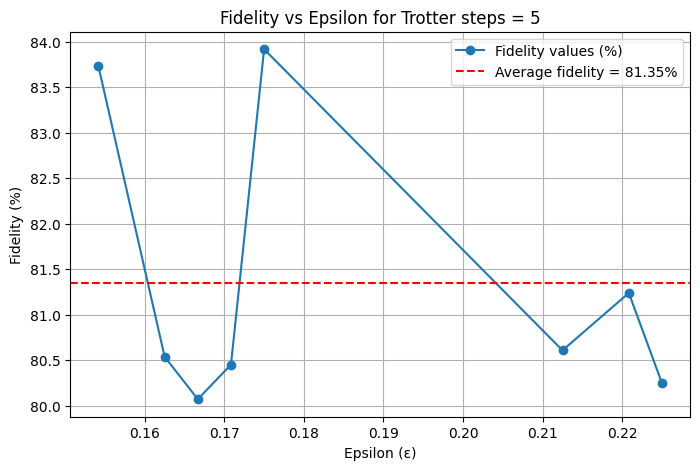

In [55]:
# Extract epsilon and fidelity values
eps_values = np.array([eps for eps, F in high_fidelity_eps])
fidelity_values = np.array([F for eps, F in high_fidelity_eps])

# Convert to percentage
fidelity_values_percent = fidelity_values * 100

# Average fidelity
avg_fidelity_percent = np.mean(fidelity_values_percent)

# Sort by epsilon
sorted_indices = np.argsort(eps_values)
eps_sorted = eps_values[sorted_indices]
fidelity_sorted = fidelity_values_percent[sorted_indices]

# Plot
plt.figure(figsize=(8,5))
plt.plot(eps_sorted, fidelity_sorted, 'o-', label='Fidelity values (%)')

# Average line
plt.axhline(avg_fidelity_percent, color='r', linestyle='--', label=f'Average fidelity = {avg_fidelity_percent:.2f}%')

plt.xlabel('Epsilon (ε)')
plt.ylabel('Fidelity (%)')
plt.title(f'Fidelity vs Epsilon for Trotter steps = {troter_steps[0]}')
plt.legend()
plt.grid(True)
plt.show()